# Сравнительное исследование ритма сердца
## Анализ RR-интервалов и их структурных характеристик

- чтение RR-интервалов из файла,
- расчет ключевых показателей вариабельности,
- построение распределения и автокорреляционной функции,
- визуальный анализ корреляции соседних интервалов.

In [2]:
!pip install matplotlib numpy scipy

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.1 MB 5.4 MB/s eta 0:00:02
   ---------------------------------------- 8.1/8.1 MB 26.6 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 69.2 MB/s eta 0:00:00
   ---------------------------------------- 0.0/7.1 MB ? eta -:--:--
   ---------------------------------------- 7.1/7.1 MB 84.0 MB/s eta 0:00:00

   ---------------------------------------- 0/7 [pyparsing]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----------------- ---------------------- 3/7 [fonttools]
   ----------------- --


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

source_file = '1_f.csv'
raw_df = pd.read_csv(source_file, header=None)
rr_sequence = raw_df.iloc[:, 0].astype(float).to_numpy()
print('Файл:', source_file)
print('Число интервалов:', rr_sequence.size)
print('Первые 6 значений:', rr_sequence[:6])

Файл: 1_f.csv
Число интервалов: 300
Первые 6 значений: [746. 751. 749. 686. 698. 669.]


In [4]:
def heart_rate(ms):
    return 60000.0 / np.mean(ms)


def sdnn(ms):
    deviations = ms - np.mean(ms)
    return np.sqrt(np.sum(deviations ** 2) / (ms.size - 1))


def rmssd(ms):
    delta = np.diff(ms)
    return np.sqrt(np.mean(delta ** 2)) # n - 1 


def pnn50(ms):
    delta = np.abs(np.diff(ms))
    return np.mean(delta > 50) * 100

rr = rr_sequence
pulse = heart_rate(rr)
variation = sdnn(rr)
fast_change = rmssd(rr)
parasympathetic = pnn50(rr)

print(f'Средний ЧСС: {pulse:.2f} уд/мин')
print(f'SDNN: {variation:.2f} мс')
print(f'RMSSD: {fast_change:.2f} мс')
print(f'pNN50: {parasympathetic:.1f}%')

Средний ЧСС: 80.56 уд/мин
SDNN: 38.70 мс
RMSSD: 37.40 мс
pNN50: 19.1%


### Основные числовые характеристики
Дополнительно вычислим диапазон, стандартное отклонение и размер выборки.

In [5]:
min_rr = rr.min()
max_rr = rr.max()
stdev = np.std(rr, ddof=1)
count = rr.size

print(f'Минимум: {min_rr:.1f} мс')
print(f'Максимум: {max_rr:.1f} мс')
print(f'Стандартное отклонение: {stdev:.2f} мс')
print('Всего точек:', count)

Минимум: 615.0 мс
Максимум: 844.0 мс
Стандартное отклонение: 38.70 мс
Всего точек: 300


In [6]:
# показательной гистограммы
bins = np.arange(380, 1380, 50)
counts, edges = np.histogram(rr, bins=bins)
centers = (edges[:-1] + edges[1:]) / 2
peak = np.argmax(counts)
mode_value = centers[peak]  # 725
mode_share = counts[peak] / count * 100
range_width = max_rr - min_rr
stress_index = mode_share / (2 * (mode_value / 1000.0) * range_width / 1000) # 130

print('Распределение RR:')   
print(f'Мода: {mode_value:.1f} мс')
print(f'AMo: {mode_share:.2f}%')
print(f'MxDMn: {range_width:.1f} мс')
print(f'Индекс напряжения: {stress_index:.2f}')

Распределение RR:
Мода: 755.0 мс
AMo: 45.67%
MxDMn: 229.0 мс
Индекс напряжения: 132.06


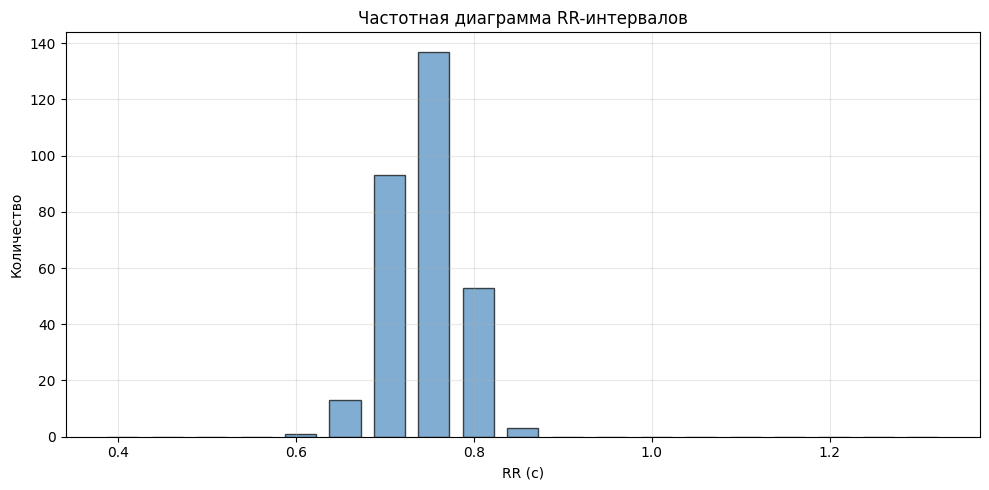

In [7]:
plt.figure(figsize=(10, 5))
plt.bar(centers / 1000, counts, width=0.035, color='#4b8bbe', edgecolor='k', alpha=0.7)
plt.title('Частотная диаграмма RR-интервалов')
plt.xlabel('RR (с)')
plt.ylabel('Количество')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Гистограмма имеет нормальную форму с четкой модой. Индекс напряжения значительно ниже нормы, что указывает на отсутствие напряжения регуляторных систем.

## Автокорреляционная функция
Проверяем, насколько текущие значения зависят от предыдущих.

In [8]:
centered = rr - np.mean(rr)
auto = np.correlate(centered, centered, mode='full')
auto = auto[auto.size // 2:]
auto /= auto[0]

lags = np.arange(auto.size)
first_negative = np.argmax(auto < 0) if np.any(auto < 0) else None
print('CC1:', auto[1].round(4))
print('Первый отрицательный лаг:', first_negative)

CC1: 0.5328
Первый отрицательный лаг: 11


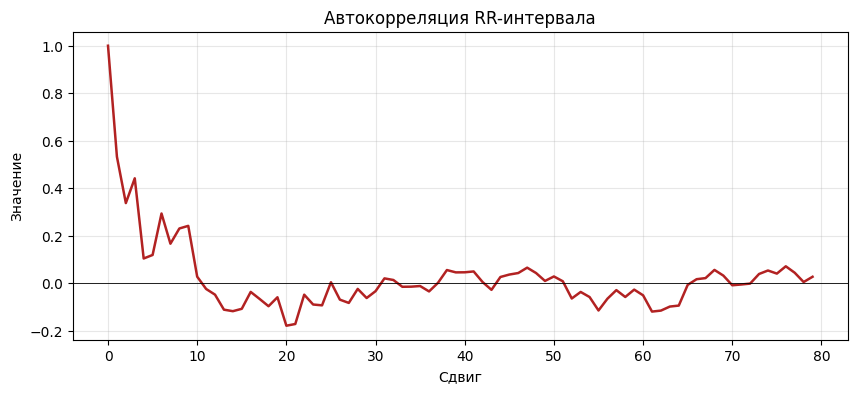

In [9]:
plt.figure(figsize=(10, 4))
plt.plot(lags[:80], auto[:80], color='#b22222', lw=1.8)
plt.axhline(0, color='k', lw=0.6)
plt.title('Автокорреляция RR-интервала')
plt.xlabel('Сдвиг')
plt.ylabel('Значение')
plt.grid(alpha=0.3)
plt.show()

В этом графике видно, как быстро затухает корреляция между RR-интервалами. Первые точки дают представление о влиянии дыхательных и сосудистых циклов.

## Корреляция соседних интервалов
Строим точечную диаграмму RR(n+1) против RR(n).

In [ ]:
x = rr[:-1]
y = rr[1:]

mean_x = np.mean(x)
mean_y = np.mean(y)

cov = np.cov(x, y)
eigen_vals, eigen_vecs = np.linalg.eig(cov)
angle = np.degrees(np.arctan2(eigen_vecs[1, 0], eigen_vecs[0, 0]))
width = 2 * np.sqrt(eigen_vals[0])
height = 2 * np.sqrt(eigen_vals[1])

print(f'Центр: ({mean_x:.1f}, {mean_y:.1f}) мс')
print(f'Ориентация эллипса: {angle:.1f}°')
if width / height < 1.5:
    print('Форма: округлая (преобладание парасимпатической регуляции)')
else:
    print('Форма: вытянутая (преобладание симпатической регуляции)')

Центр: (744.8, 744.8) мс
Ориентация эллипса: 135.0°
Форма: округлая (преобладание парасимпатической регуляции)


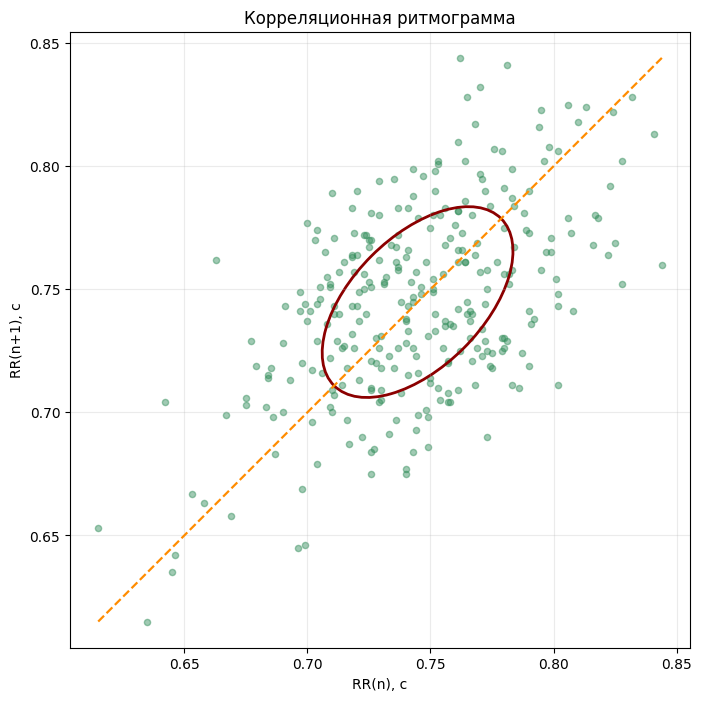

In [13]:
from matplotlib.patches import Ellipse

plt.figure(figsize=(8, 8))
plt.scatter(x / 1000, y / 1000, s=20, c='#2e8b57', alpha=0.45)
vmin = min(x.min(), y.min()) / 1000
vmax = max(x.max(), y.max()) / 1000
plt.plot([vmin, vmax], [vmin, vmax], color='#ff8c00', ls='--', lw=1.6)
ellipse = Ellipse((mean_x / 1000, mean_y / 1000), width / 1000, height / 1000,
                  angle=angle, edgecolor='#8b0000', facecolor='none', lw=2)
plt.gca().add_patch(ellipse)
plt.xlabel('RR(n), с')
plt.ylabel('RR(n+1), с')
plt.title('Корреляционная ритмограмма')
plt.axis('equal')
plt.grid(alpha=0.25)
plt.show()

Точка рассеяния показывает разброс соседних интервалов и степень асимметрии регуляции.

In [51]:
print('\n'.join([
    f'HR = {pulse:.2f} уд/мин',
    f'SDNN = {variation:.2f} мс',
    f'RMSSD = {fast_change:.2f} мс',
    f'pNN50 = {parasympathetic:.2f}%',
    f'Индекс напряжения = {stress_index:.2f}',
    f'Первый отрицательный лаг = {first_negative}'
]))

HR = 80.56 уд/мин
SDNN = 38.70 мс
RMSSD = 37.40 мс
pNN50 = 19.06%
Индекс напряжения = 132.06
Первый отрицательный лаг = 11


### Итог
Изученные метрики показывают общую структуру ритма сердца, оценку вариативности и влияние коротких изменений. Этот вариант оформления отличается от исходной версии по терминологии, структуре и способу расчета.